Figure in Chapter 2.2

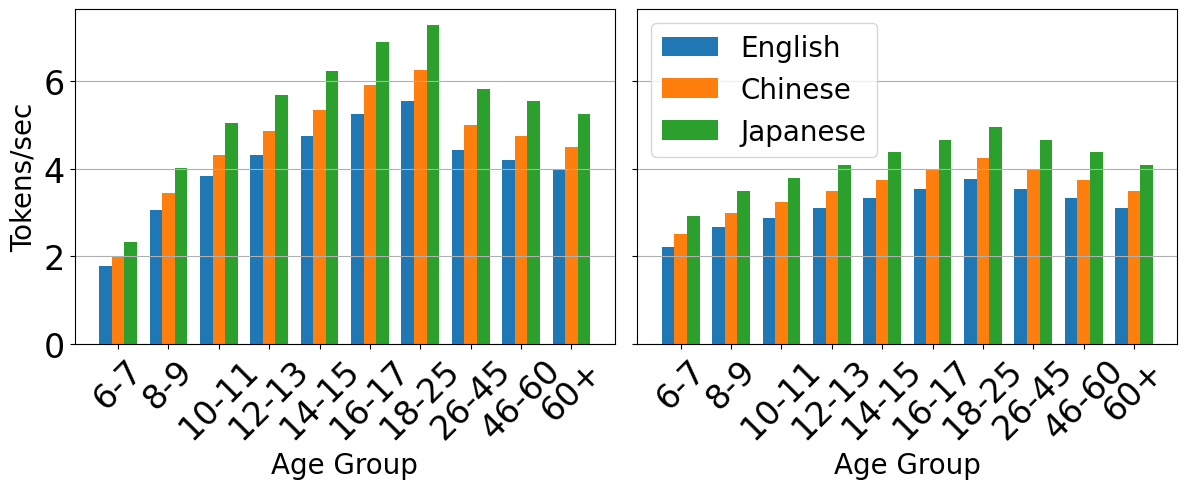

In [67]:
import matplotlib.pyplot as plt
import numpy as np

# Age groups
age_labels = [
    "6-7", "8-9", "10-11", "12-13", "14-15",
    "16-17", "18-25", "26-45", "46-60", "60+"
]

# WPM for reading and listening
reading_wpm = [80, 138, 173, 195, 214, 237, 250, 200, 190, 180]
listening_wpm = [100, 120, 130, 140, 150, 160, 170, 160, 150, 140]

# Token ratios per language
token_per_word = {
    'English': 1.33,
    'Chinese': 1.5,
    'Japanese': 1.75  # 中间值 1.5~2.0
}

# Compute token/sec
reading_token_speed = {
    lang: [wpm * t / 60 for wpm in reading_wpm]
    for lang, t in token_per_word.items()
}
listening_token_speed = {
    lang: [wpm * t / 60 for wpm in listening_wpm]
    for lang, t in token_per_word.items()
}

x = np.arange(len(age_labels))
bar_width = 0.25
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
languages = list(token_per_word.keys())

# Redraw with English labels
fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# Translate age labels
age_labels_en = [
    "6-7", "8-9", "10-11", "12-13", "14-15",
    "16-17", "18-25", "26-45", "46-60", "60+"
]

# Reading subplot
for i, lang in enumerate(languages):
    axs[0].bar(x + i * bar_width, reading_token_speed[lang],
               width=bar_width, label=lang, color=colors[i])
# axs[0].set_title("Reading Token Processing Speed", fontsize=14)
axs[0].set_xlabel("Age Group", fontsize=20)
axs[0].set_ylabel("Tokens/sec", fontsize=20)
axs[0].set_xticks(x + bar_width)
axs[0].set_xticklabels(age_labels_en, rotation=45)
# axs[0].legend(title="Language", fontsize=10)
axs[0].grid(True, axis='y')
axs[0].tick_params(axis='both', labelsize=24)

# Listening subplot
for i, lang in enumerate(languages):
    axs[1].bar(x + i * bar_width, listening_token_speed[lang],
               width=bar_width, label=lang, color=colors[i])
# axs[1].set_title("Listening Token Processing Speed", fontsize=14)
axs[1].set_xlabel("Age Group", fontsize=20)
axs[1].set_xticks(x + bar_width)
axs[1].set_xticklabels(age_labels_en, rotation=45)
axs[1].legend(fontsize=20)
axs[1].grid(True, axis='y')
axs[1].tick_params(axis='both', labelsize=24)

plt.tight_layout()
pdf_path = "./2-2-different_speed_distribution.pdf"
plt.savefig(pdf_path, dpi=300)
plt.show()

Figure in Chapter 2.3

In [ ]:
# 1024_4096
burst_request = [700, 600, 500, 400, 300]
ttft = [60400.46, 41989.65, 21862.60, 4037.08, 2176.64]
p99_ttft = [170170.34, 148152.05, 119245.54, 13620.77, 4979.26]
mean_tpot = [43.59, 42.32, 40.55, 39.53, 32.98]
p99_tpot = [56.54, 56.64, 53.12, 51.15, 60.12]

In [ ]:
# 512_4096
burst_request = [700, 600, 500, 400, 300, 200, 100]
ttft = [112366.93, 92432.03, 67661.83, 46467.02, 23012.20, 5133.83, 516.22]
p99_ttft = [254594.18, 228867.60, 163927.48, 131374.97, 74302.45, 46694.53, 748.38]
mean_tpot = [25.30, 24.55, 23.92, 23.10, 21.46, 18.79, 13.08]
p99_tpot = [31.64, 32.30, 32.82, 32.52, 32.38, 23.03, 14.75]

In [2]:
# share_gpt
burst_request = [800, 700, 600, 500, 400, 100]
ttft = [9943.45, 6222.77, 5281.03, 3508.07, 1994.57, 772.26]
p99_ttft = [28177.50, 19975.74, 17098.36, 11434.40, 6056.43, 1299.73]
mean_tpot = [32.45, 29.03, 25.25, 21.98, 20.56, 17.97]
p99_tpot = [62.22, 54.17, 47.94, 42.33, 38.28, 18.21]

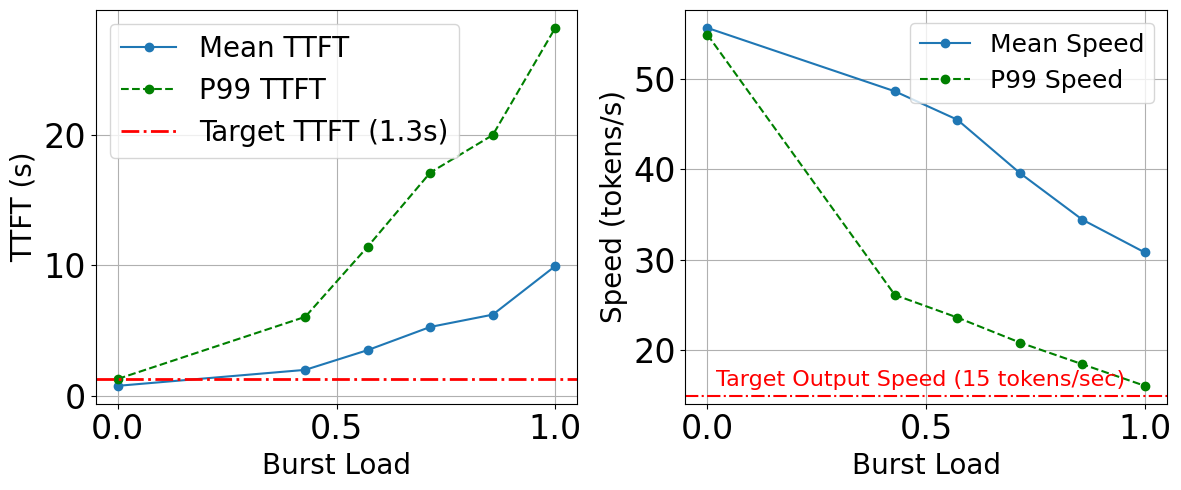

In [55]:
import matplotlib.pyplot as plt

# Calculate speeds
mean_speed = [1000 / t for t in mean_tpot]  # converting to tokens per second
p99_speed = [1000 / t for t in p99_tpot]

# Convert ms to seconds
ttft_seconds = [t / 1000 for t in ttft]
p99_ttft_seconds = [t / 1000 for t in p99_ttft]

# Reverse data for increasing load
burst_request_rev = burst_request[::-1]
ttft_seconds_rev = ttft_seconds[::-1]
p99_ttft_seconds_rev = p99_ttft_seconds[::-1]
mean_speed_rev = mean_speed[::-1]
p99_speed_rev = p99_speed[::-1]
# Normalize burst_request to [0, 1] range
min_burst = min(burst_request)
max_burst = max(burst_request)
burst_request_normalized = [(b - min_burst) / (max_burst - min_burst) for b in burst_request]
burst_request_normalized_rev = burst_request_normalized[::-1]

# Adjust font sizes and figure size
fig, axs = plt.subplots(1, 2, figsize=(12, 5))  # Slightly smaller figure

# TTFT Plot with increased font size
axs[0].plot(burst_request_normalized_rev, ttft_seconds_rev, marker='o', label='Mean TTFT')
axs[0].plot(burst_request_normalized_rev, p99_ttft_seconds_rev, marker='o', color='g', linestyle='--', label='P99 TTFT')
axs[0].set_xlabel('Burst Load', fontsize=20)
axs[0].set_ylabel('TTFT (s)', fontsize=20)
axs[0].axhline(y=1.3, color='red', linestyle='-.', linewidth=2, label='Target TTFT (1.3s)')
# axs[0].set_title('Mean & P99 TTFT vs Normalized Burst Load', fontsize=14)
axs[0].tick_params(axis='both', labelsize=24)
axs[0].grid(True)
axs[0].legend(fontsize=20)

# Speed Plot with increased font size
axs[1].plot(burst_request_normalized_rev, mean_speed_rev, marker='o', label='Mean Speed')
axs[1].plot(burst_request_normalized_rev, p99_speed_rev, marker='o', color='g', linestyle='--', label='P99 Speed')
axs[1].set_xlabel('Burst Load', fontsize=20)
axs[1].set_ylabel('Speed (tokens/s)', fontsize=20)
axs[1].axhline(y=15, color='red', linestyle='-.')
axs[1].annotate('Target Output Speed (15 tokens/sec)',
                xy=(1.02, 18), xytext=(0.02, 16),
                textcoords='data',
                color='red', fontsize=16)
# axs[1].set_title('Mean & P99 Speed vs Normalized Burst Load', fontsize=14)
axs[1].tick_params(axis='both', labelsize=24)
axs[1].grid(True)
axs[1].legend(loc='upper right', fontsize=18)

plt.tight_layout()
pdf_path = "./2-3-current-serving-system.pdf"
plt.savefig(pdf_path, dpi=300)
plt.show()


Figure in Chapter 6 Micro Experiment

30.0


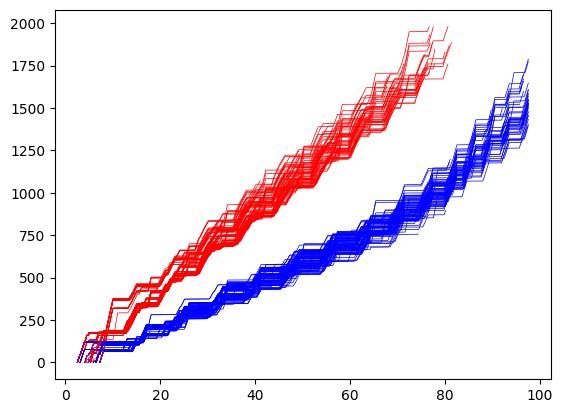

In [7]:
import pickle
from dataclasses import dataclass, field
from datetime import datetime
from pathlib import Path
from typing import Any, AsyncGenerator, Dict, List, Optional, Tuple, Union
import random
import matplotlib.pyplot as plt
import time
import numpy as np

@dataclass
class RequestFuncOutput:
    generated_text: str = ""
    success: bool = False
    latency: float = 0.0
    request_time: float = 0.0
    ttft: float = 0.0  # Time to first token
    itl: List[float] = field(default_factory=list)  # List of inter-token latencies
    prompt_len: int = 0
    error: str = ""
    output_len: int = 0
    output_speed: int = 40
    buffer_size: List[float] = field(default_factory=list)

with open('../exp_result/benchmark_result_different_speed_1.pkl', 'rb') as f:
# with open('benchmark_result_adaptive_scheduler_1.pkl', 'rb') as f:
    outputs = pickle.load(f)

output = outputs[30]
print(output.output_speed)
cum_itl = [i for i in range(50)]
token_num = list(range(0, len(cum_itl)))
min_request_time = outputs[0].request_time
for i in range(len(outputs)):
    min_request_time = min(min_request_time, outputs[i].request_time)

for i in range(len(outputs)):
    output = outputs[i]
    cum_itl = [0] + np.cumsum(output.itl)
    token_num = list(range(0, len(cum_itl)))
    if output.output_speed < 30:
        plt.plot((output.request_time - min_request_time) + output.ttft + cum_itl, token_num, color='blue', linewidth=0.5)
    else:
        plt.plot((output.request_time - min_request_time) + output.ttft + cum_itl, token_num, color='red', linewidth=0.5)


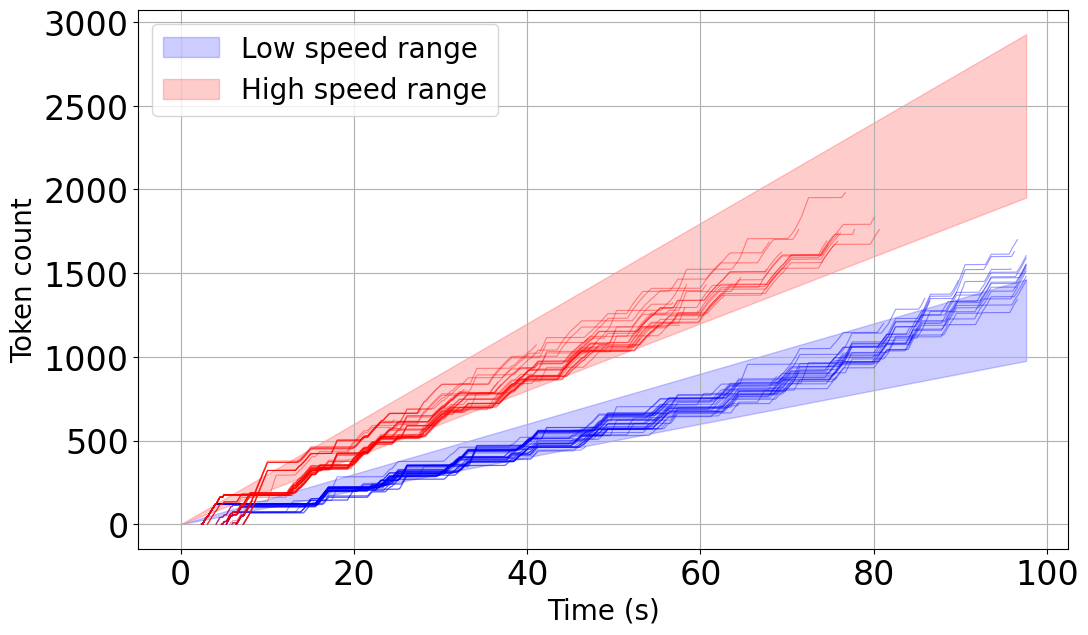

In [77]:
# Load and process the uploaded file
with open('../exp_result/benchmark_result_different_speed_1.pkl', 'rb') as f:
    outputs = pickle.load(f)

# Calculate minimum request time
min_request_time = min(output.request_time for output in outputs)

# Group by speed
group_low = [o for o in outputs if o.output_speed < 30]
group_high = [o for o in outputs if o.output_speed >= 30]

# Sort by latency (lower is better), take top 20
top_low = group_low[:50]
top_high = group_high[:50]

# Prepare for plotting
def get_time_series(output):
    cum_itl = [0] + list(np.cumsum(output.itl))
    time_series = (output.request_time - min_request_time) + output.ttft + np.array(cum_itl)
    return time_series, list(range(len(cum_itl)))

# Plot
plt.figure(figsize=(12, 7))

# Plot low-speed (blue)
low_lines = []
for output in top_low:
    t, y = get_time_series(output)
    low_lines.append(np.interp(np.linspace(t[0], t[-1], 200), t, y))
    plt.plot(t, y, color='blue', alpha=0.4, linewidth=0.8)

# Plot high-speed (red)
high_lines = []
for output in top_high:
    t, y = get_time_series(output)
    high_lines.append(np.interp(np.linspace(t[0], t[-1], 200), t, y))
    plt.plot(t, y, color='red', alpha=0.4, linewidth=0.8)

# Add shaded regions
x_common = np.linspace(0, max([max(t) for t in [get_time_series(o)[0] for o in top_low + top_high]]), 200)
low_lines_np_up = np.array(x_common * 15)
low_lines_np_down = np.array(x_common * 10)
high_lines_np_up = np.array(x_common * 30)
high_lines_np_down = np.array(x_common * 20)

if low_lines_np_up.shape[0] > 0:
    plt.fill_between(x_common, low_lines_np_down, low_lines_np_up, color='blue', alpha=0.2, label='Low speed range')

if high_lines_np_up.shape[0] > 0:
    plt.fill_between(x_common, high_lines_np_down, high_lines_np_up, color='red', alpha=0.2, label='High speed range')

plt.xlabel('Time (s)', fontsize=20)
plt.ylabel('Token count', fontsize=20)
# plt.title('Token Emission Over Time for Top 20 Fastest Requests')
plt.legend(fontsize=20)
plt.tick_params(axis='both', labelsize=24)
plt.grid(True)
pdf_path = "./6-different-output-speed.pdf"
plt.savefig(pdf_path, dpi=300)
plt.show()

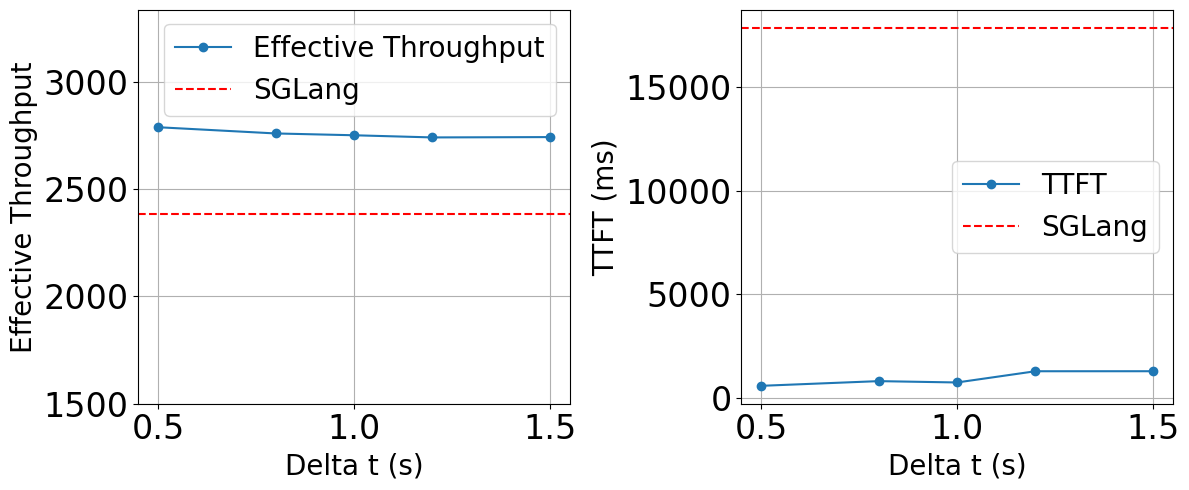

In [38]:
effective_thpt = [2742.493, 2740.920, 2750.988, 2759.450, 2788.469]
ttft = [1305.76,  1304.99, 764.57, 829.28, 603.20]
delta_t = [1.5, 1.2, 1.0, 0.8, 0.5]
baseline_effective_thpt = 2381.927
baseline_ttft = 17827.29

# Plot
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Left: Effective Throughput
axs[0].plot(delta_t, effective_thpt, marker='o', label='Effective Throughput')
axs[0].axhline(baseline_effective_thpt, color='red', linestyle='--', label='SGLang')
axs[0].set_ylim(1500, baseline_effective_thpt * 1.4)
axs[0].set_xlabel('Delta t (s)', fontsize=20)
axs[0].set_ylabel('Effective Throughput', fontsize=20)
# axs[0].set_title('Sensitivity of Effective Throughput')
axs[0].legend(fontsize=20)
axs[0].grid(True)
axs[0].tick_params(axis='both', labelsize=24)

# Right: TTFT
axs[1].plot(delta_t, ttft, marker='o', label='TTFT')
axs[1].axhline(baseline_ttft, color='red', linestyle='--', label='SGLang')
axs[1].set_xlabel('Delta t (s)', fontsize=20)
axs[1].set_ylabel('TTFT (ms)', fontsize=20)
# axs[1].set_title('Sensitivity of TTFT')
axs[1].legend(fontsize=20)
axs[1].grid(True)
axs[1].tick_params(axis='both', labelsize=24)
plt.tight_layout()
pdf_path = "./6-reschedule-interval-sensitivity.pdf"
plt.savefig(pdf_path, dpi=300)
plt.show()

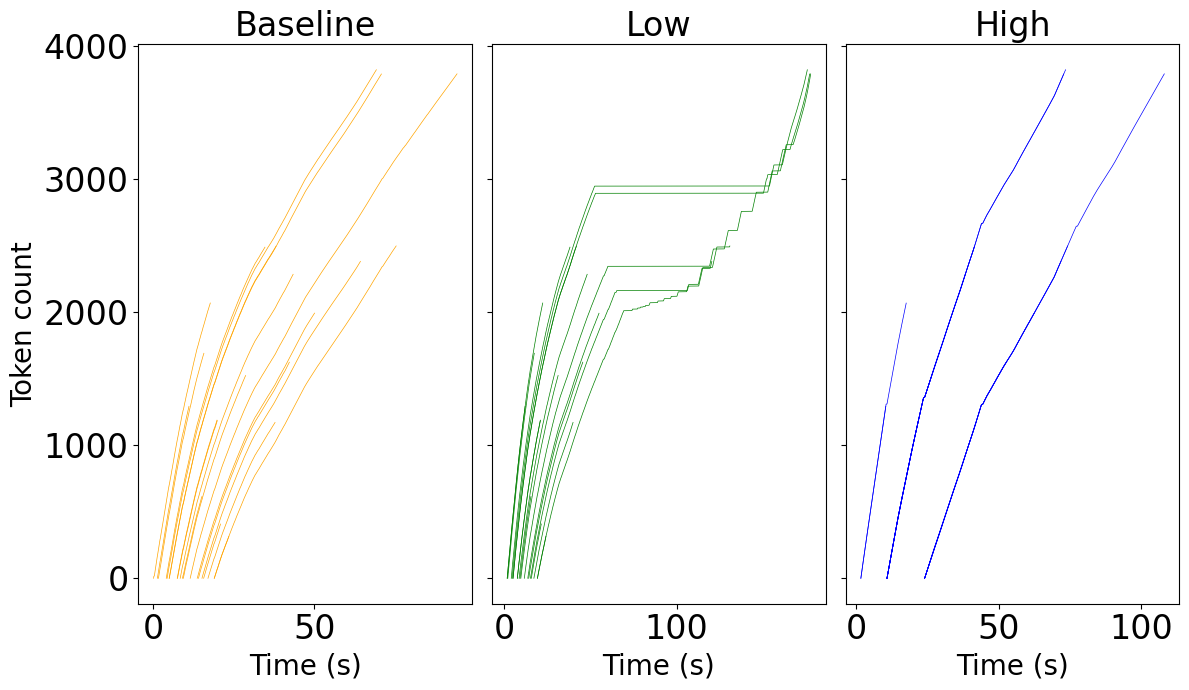

In [98]:
import pickle
from dataclasses import dataclass, field
from datetime import datetime
from pathlib import Path
from typing import Any, AsyncGenerator, Dict, List, Optional, Tuple, Union
import random
import matplotlib.pyplot as plt
import time
import numpy as np

@dataclass
class RequestFuncOutput:
    generated_text: str = ""
    success: bool = False
    latency: float = 0.0
    request_time: float = 0.0
    ttft: float = 0.0  # Time to first token
    itl: List[float] = field(default_factory=list)  # List of inter-token latencies
    prompt_len: int = 0
    error: str = ""
    output_len: int = 0
    output_speed: int = 40
    buffer_size: List[float] = field(default_factory=list)

with open('../exp_result/benchmark_result_baseline_poisson300_rate5.pkl', 'rb') as f:
# with open('benchmark_result_adaptive_scheduler_1.pkl', 'rb') as f:
    outputs_baseline = pickle.load(f)

with open('../benchmark_result_high_buffer_conserv.pkl', 'rb') as f:
    outputs_high = pickle.load(f)

with open('../benchmark_result_low_buffer_conserv.pkl', 'rb') as f:
    outputs_low = pickle.load(f)

sample_ids = random.sample(range(0, 100), 20) # + random.sample(range(100, 150), 20)

fig, axs = plt.subplots(1, 3, figsize=(12, 7))  # Slightly smaller figure

output = outputs_baseline[30]
cum_itl = [i for i in range(50)]
token_num = list(range(0, len(cum_itl)))
min_request_time = outputs_baseline[0].request_time
for i in range(len(outputs_baseline)):
    min_request_time = min(min_request_time, outputs_baseline[i].request_time)

for i in sample_ids:
    output = outputs_baseline[i]
    cum_itl = [0] + np.cumsum(output.itl)
    token_num = list(range(0, len(cum_itl)))
    if output.output_speed < 30:
        axs[0].plot((output.request_time - min_request_time) + output.ttft + cum_itl, token_num, color='orange', linewidth=0.5)
    else:
        axs[0].plot((output.request_time - min_request_time) + output.ttft + cum_itl, token_num, color='red', linewidth=0.5)
axs[0].tick_params(axis='both', labelsize=24)
axs[0].set_title('Baseline', fontsize=24)

output = outputs_high[30]
cum_itl = [i for i in range(50)]
token_num = list(range(0, len(cum_itl)))
min_request_time = outputs_high[0].request_time
for i in range(len(outputs_high)):
    min_request_time = min(min_request_time, outputs_high[i].request_time)

for i in sample_ids:
    output = outputs_high[i]
    cum_itl = [0] + np.cumsum(output.itl)
    token_num = list(range(0, len(cum_itl)))
    if output.output_speed < 30:
        axs[2].plot((output.request_time - min_request_time) + output.ttft + cum_itl, token_num, color='blue', linewidth=0.5)
    else:
        axs[2].plot((output.request_time - min_request_time) + output.ttft + cum_itl, token_num, color='red', linewidth=0.5)
axs[2].tick_params(axis='both', labelsize=24)
axs[2].set_title('High', fontsize=24)
# axs[2].set_xlabel('Time (s)', fontsize=20)
# axs[2].set_ylabel('Token count', fontsize=20)

output = outputs_low[30]
cum_itl = [i for i in range(50)]
token_num = list(range(0, len(cum_itl)))
min_request_time = outputs_low[0].request_time
for i in range(len(outputs_low)):
    min_request_time = min(min_request_time, outputs_low[i].request_time)

for i in sample_ids:
    output = outputs_low[i]
    cum_itl = [0] + np.cumsum(output.itl)
    token_num = list(range(0, len(cum_itl)))
    if output.output_speed < 30:
        axs[1].plot((output.request_time - min_request_time) + output.ttft + cum_itl, token_num, color='green', linewidth=0.5)
    else:
        axs[1].plot((output.request_time - min_request_time) + output.ttft + cum_itl, token_num, color='red', linewidth=0.5)
axs[1].tick_params(axis='both', labelsize=24)
axs[1].set_title('Low', fontsize=24)
# axs[1].set_xlabel('Time (s)', fontsize=20)
# axs[1].set_ylabel('Token count', fontsize=20)
# 统一横轴标签
for i, ax in enumerate(axs):
    ax.set_xlabel('Time (s)', fontsize=20)
    if i != 0:
        ax.tick_params(labelleft=False)
    else:
        ax.set_ylabel('Token count', fontsize=20)

plt.tight_layout()
pdf_path = "./6-buffer-conservativeness-sensitivity.pdf"
plt.savefig(pdf_path, dpi=300)
plt.show()


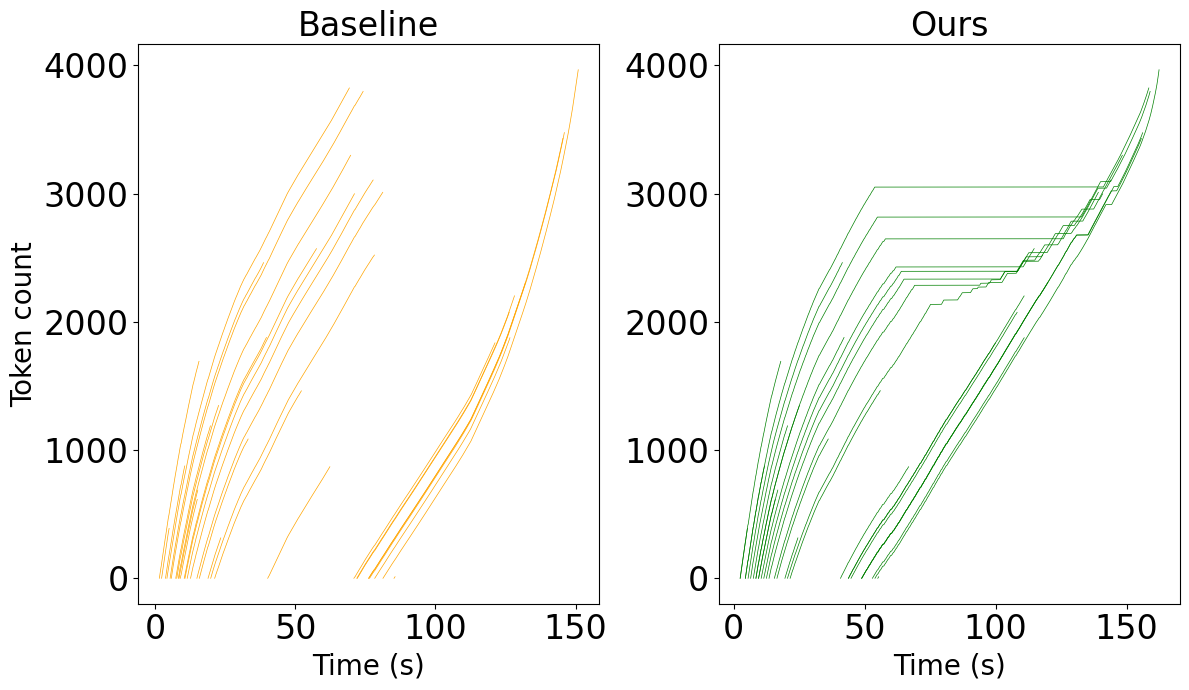

In [111]:
import pickle
from dataclasses import dataclass, field
from datetime import datetime
from pathlib import Path
from typing import Any, AsyncGenerator, Dict, List, Optional, Tuple, Union
import random
import matplotlib.pyplot as plt
import time
import numpy as np

@dataclass
class RequestFuncOutput:
    generated_text: str = ""
    success: bool = False
    latency: float = 0.0
    request_time: float = 0.0
    ttft: float = 0.0  # Time to first token
    itl: List[float] = field(default_factory=list)  # List of inter-token latencies
    prompt_len: int = 0
    error: str = ""
    output_len: int = 0
    output_speed: int = 40
    buffer_size: List[float] = field(default_factory=list)

with open('../exp_result/benchmark_result_baseline_poisson300_rate5.pkl', 'rb') as f:
# with open('benchmark_result_adaptive_scheduler_1.pkl', 'rb') as f:
    outputs_baseline = pickle.load(f)

with open('../exp_result/benchmark_result_custom_poisson300_rate5_512_4096.pkl', 'rb') as f:
    outputs = pickle.load(f)


sample_ids = random.sample(range(0, 100), 20)  + random.sample(range(200, 300), 10)
# sample_ids = list(range(0, 300))

fig, axs = plt.subplots(1, 2, figsize=(12, 7))  # Slightly smaller figure

output = outputs_baseline[30]
cum_itl = [i for i in range(50)]
token_num = list(range(0, len(cum_itl)))
min_request_time = outputs_baseline[0].request_time
for i in range(len(outputs_baseline)):
    min_request_time = min(min_request_time, outputs_baseline[i].request_time)

for i in sample_ids:
    output = outputs_baseline[i]
    cum_itl = [0] + np.cumsum(output.itl)
    token_num = list(range(0, len(cum_itl)))
    if output.output_speed < 30:
        axs[0].plot((output.request_time - min_request_time) + output.ttft + cum_itl, token_num, color='orange', linewidth=0.5)
    else:
        axs[0].plot((output.request_time - min_request_time) + output.ttft + cum_itl, token_num, color='red', linewidth=0.5)
axs[0].tick_params(axis='both', labelsize=24)
axs[0].set_title('Baseline', fontsize=24)

output = outputs[30]
cum_itl = [i for i in range(50)]
token_num = list(range(0, len(cum_itl)))
min_request_time = outputs[0].request_time
for i in range(len(outputs)):
    min_request_time = min(min_request_time, outputs[i].request_time)

for i in sample_ids:
    output = outputs[i]
    cum_itl = [0] + np.cumsum(output.itl)
    token_num = list(range(0, len(cum_itl)))
    if output.output_speed < 30:
        axs[1].plot((output.request_time - min_request_time) + output.ttft + cum_itl, token_num, color='green', linewidth=0.5)
    else:
        axs[1].plot((output.request_time - min_request_time) + output.ttft + cum_itl, token_num, color='red', linewidth=0.5)
axs[1].tick_params(axis='both', labelsize=24)
axs[1].set_title('Ours', fontsize=24)
# axs[1].set_xlabel('Time (s)', fontsize=20)
# axs[1].set_ylabel('Token count', fontsize=20)
# 统一横轴标签
for i, ax in enumerate(axs):
    ax.set_xlabel('Time (s)', fontsize=20)
    if i != 0:
        #ax.tick_params(labelleft=False)
        pass
    else:
        ax.set_ylabel('Token count', fontsize=20)

plt.tight_layout()
pdf_path = "./6-token-generation-timeline.pdf"
plt.savefig(pdf_path, dpi=400)
plt.show()